# Lotus Hotels Booking Analysis

## Project Objective
This project analyzes hotel booking behavior, customer cancellation patterns, pricing trends, and operational demand fluctuations for Lotus Hotels.

The objective is to identify:
- key operational inefficiencies
- revenue instability factors
- customer behavior patterns
- business opportunities for operational improvement

## Business Goals
- Understand cancellation behavior
- Identify high-risk customer segments
- Explore revenue volatility
- Analyze seasonal demand patterns
- Generate actionable business recommendations

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Loading

The cleaned hotel booking dataset is loaded from the processed data layer.

In [23]:
df = pd.read_csv("../data/processed/hotel_bookings_clean.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Initial Data Inspection

Initial exploratory analysis is performed to understand:
- dataset dimensions
- available business metrics
- customer-related fields
- operational data structure

In [24]:
df.shape

(87396, 32)

In [25]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [26]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

# Initial Observations

## Observations
- Dataset contains hotel booking transaction records.
- Both operational and customer-related metrics are available.
- Booking cancellations, pricing, and stay duration metrics are included.
- Data includes both Resort Hotel and City Hotel operations.

## Potential Business Questions
- Which customers are most likely to cancel?
- Which hotel type experiences greater operational instability?
- How do pricing and booking timing affect cancellations?
- Are there seasonal demand fluctuations?

# Cancellation Analysis

This section investigates booking cancellation behavior to identify operational instability and high-risk customer segments.

In [28]:
cancellation_rate = df["is_canceled"].mean() * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 27.49%


## Cancellation Rate Insight

The overall cancellation rate is approximately 27.5%, meaning more than 1 in 4 bookings are canceled.

### Business Implications
- Revenue forecasting may become unreliable.
- Staffing and room allocation planning may become inefficient.
- Operational instability may increase during peak periods.

In [29]:
(
    df.groupby("customer_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

customer_type
Transient          30.105854
Contract           16.310927
Transient-Party    15.238339
Group               9.926471
Name: is_canceled, dtype: float64

## Customer Cancellation Analysis

Transient customers show the highest cancellation rate at approximately 30%.

### Business Interpretation
Transient customers may:
- be more price-sensitive
- book further in advance
- compare multiple hotel options
- exhibit less predictable booking behavior

### Operational Implications
Transient customers represent the highest operational risk segment for Lotus Hotels.

In [30]:
(
    df.groupby("hotel")["is_canceled"]
    .mean()
    * 100
)

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64

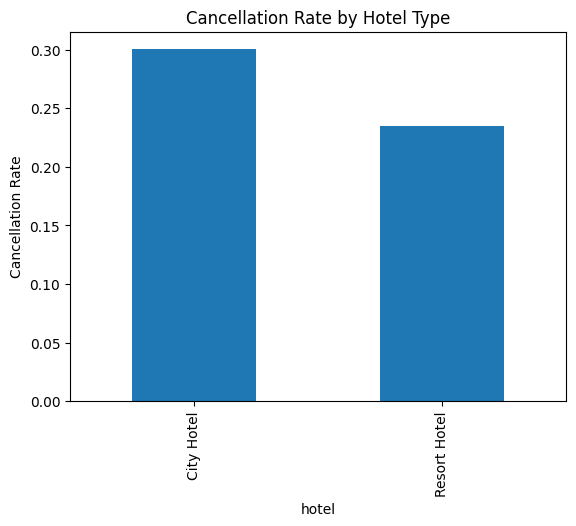

In [31]:
(
    df.groupby("hotel")["is_canceled"]
    .mean()
    .plot(kind="bar")
)

plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancellation Rate")

plt.show()

## Hotel Type Cancellation Analysis

City Hotels experience higher cancellation rates compared to Resort Hotels.

### Possible Causes
- business travel volatility
- short-term urban bookings
- price competition
- shorter booking commitment cycles

### Business Implications
City Hotel operations may require:
- stricter cancellation policies
- dynamic pricing adjustments
- improved forecasting models

# Lead Time Analysis

Lead time measures how far in advance customers make bookings.

In [32]:
df["lead_time"].describe()

count    87396.000000
mean        79.891368
std         86.052325
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64

In [33]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     70.099588
1    105.719251
Name: lead_time, dtype: float64

## Lead Time Insights

Bookings with longer lead times appear more likely to be canceled.

### Business Interpretation
Customers booking far in advance may:
- change travel plans
- continue searching for alternatives
- react to price fluctuations

### Operational Implications
Long booking lead times increase forecasting uncertainty and inventory instability.

# Revenue Analysis

This section investigates Average Daily Rate (ADR) trends and pricing-related operational risks.

In [34]:
df["adr"].describe()

count    87396.000000
mean       106.337246
std         55.013953
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

In [35]:
df.groupby("is_canceled")["adr"].mean()

is_canceled
0    102.001961
1    117.772476
Name: adr, dtype: float64

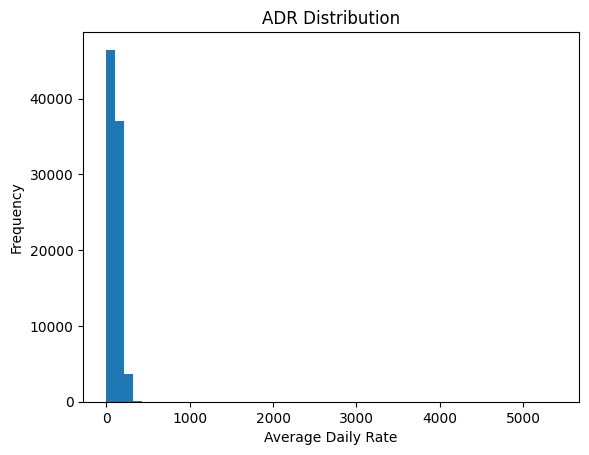

In [36]:
df["adr"].plot(kind="hist", bins=50)

plt.title("ADR Distribution")
plt.xlabel("Average Daily Rate")

plt.show()

In [37]:
df["adr"].sort_values(ascending=False).head(10)

38749    5400.00
80728     510.00
11661     508.00
74461     451.50
9984      450.00
10214     437.00
33093     426.25
33489     402.00
33056     397.38
10150     392.00
Name: adr, dtype: float64

## Revenue Insights

Canceled bookings have a higher average ADR compared to completed bookings.

### Business Interpretation
Higher-paying customers may:
- demonstrate greater booking volatility
- compare premium hotel options more aggressively
- contribute to unstable revenue forecasting

### Data Quality Observations
- Negative ADR values suggest possible accounting adjustments or data quality issues.
- Extremely high ADR values may represent luxury bookings or pricing anomalies.

### Operational Implications
Revenue forecasting accuracy may be impacted by:
- cancellation volatility
- pricing inconsistencies
- high-value booking instability

# Seasonal Demand Analysis

This section investigates booking fluctuations across different months.

In [38]:
df["arrival_date_month"].value_counts()

arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

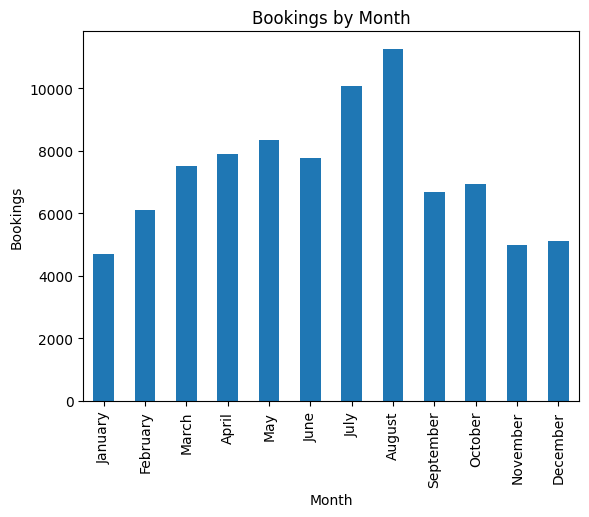

In [39]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_bookings = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

monthly_bookings.plot(kind="bar")

plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Bookings")

plt.show()

## Seasonal Trend Insights

Booking activity peaks during July and August, while January and November show lower demand.

### Business Interpretation
Demand fluctuations are likely influenced by:
- summer tourism
- holiday travel periods
- seasonal travel behavior

### Operational Implications
Seasonal demand volatility affects:
- staffing requirements
- pricing strategy
- room inventory planning
- marketing campaign timing

# Market Segment Analysis

This section investigates booking behavior across customer acquisition channels and market segments.

The objective is to identify:
- unstable booking sources
- high-risk customer channels
- operational volatility drivers
- potential revenue forecasting risks

In [40]:
df["market_segment"].value_counts()

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

## Market Segment Overview

The dataset contains multiple booking acquisition channels, including online travel agencies, direct bookings, and corporate channels.

Different booking channels may demonstrate varying cancellation behavior and operational reliability.

In [41]:
(
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

market_segment
Undefined        100.000000
Online TA         35.346197
Groups            27.013355
Aviation          19.823789
Offline TA/TO     14.853481
Direct            14.715351
Complementary     12.535613
Corporate         12.108262
Name: is_canceled, dtype: float64

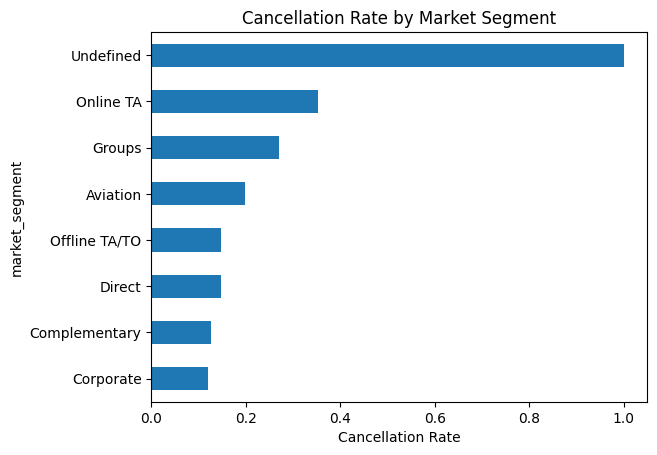

In [42]:
(
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .sort_values()
    .plot(kind="barh")
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate")

plt.show()

## Market Segment Insights

Certain booking acquisition channels demonstrate significantly higher cancellation rates than others.

### Business Interpretation
High-risk booking channels may:
- reduce forecasting accuracy
- increase operational instability
- contribute to inefficient room allocation

### Operational Implications
Lotus Hotels may benefit from:
- optimizing customer acquisition strategy
- reducing dependency on unstable booking channels
- improving cancellation management policies

# Repeat Guest Analysis

This section investigates whether returning customers demonstrate more stable booking behavior compared to first-time guests.

In [43]:
df["is_repeated_guest"].value_counts()

is_repeated_guest
0    83981
1     3415
Name: count, dtype: int64

In [44]:
(
    df.groupby("is_repeated_guest")["is_canceled"]
    .mean()
    * 100
)

is_repeated_guest
0    28.296877
1     7.642753
Name: is_canceled, dtype: float64

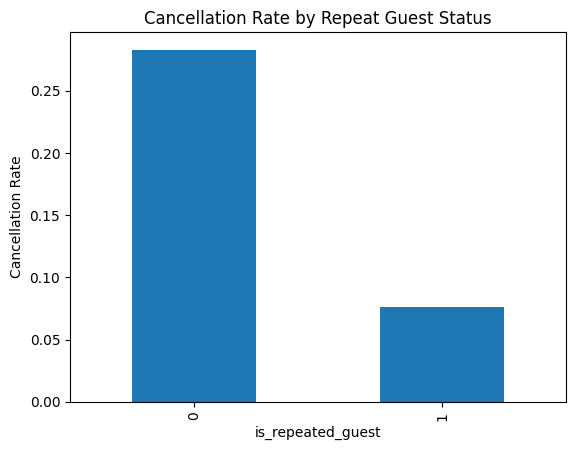

In [45]:
(
    df.groupby("is_repeated_guest")["is_canceled"]
    .mean()
    .plot(kind="bar")
)

plt.title("Cancellation Rate by Repeat Guest Status")
plt.ylabel("Cancellation Rate")

plt.show()

## Repeat Guest Insights

Returning customers may demonstrate lower cancellation behavior compared to first-time guests.

### Business Interpretation
Customer loyalty may improve:
- booking stability
- revenue predictability
- operational consistency

### Strategic Implications
Lotus Hotels may benefit from:
- loyalty programs
- repeat-customer incentives
- customer retention strategies

# Stay Duration Analysis

This section investigates customer stay behavior and operational room utilization patterns.

In [46]:
df["total_nights"] = (
    df["stays_in_week_nights"] +
    df["stays_in_weekend_nights"]
)

In [47]:
df["total_nights"].describe()

count    87396.000000
mean         3.630658
std          2.763449
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_nights, dtype: float64

In [48]:
df.groupby("is_canceled")["total_nights"].mean()

is_canceled
0    3.487557
1    4.008117
Name: total_nights, dtype: float64

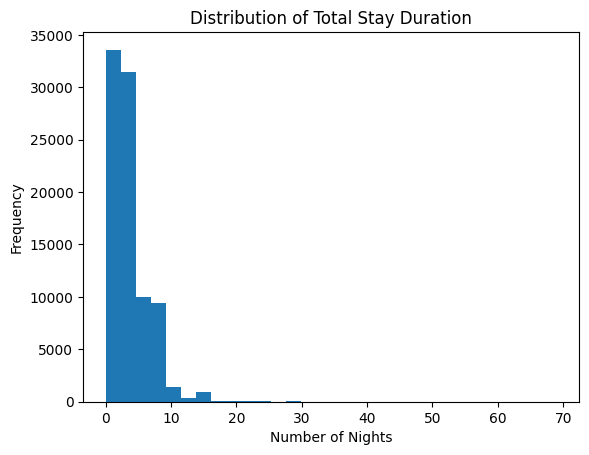

In [49]:
df["total_nights"].plot(kind="hist", bins=30)

plt.title("Distribution of Total Stay Duration")
plt.xlabel("Number of Nights")

plt.show()

## Stay Duration Insights

Customer stay durations vary significantly across bookings.

### Business Interpretation
Longer stays may:
- increase room utilization efficiency
- improve revenue consistency
- reduce operational turnover costs

### Operational Implications
Understanding stay duration behavior may help:
- optimize room inventory planning
- improve occupancy forecasting
- support pricing strategy adjustments

# Correlation Analysis

This section investigates relationships between numerical operational variables.

In [50]:
numeric_df = df.select_dtypes(include=["number"])

In [51]:
correlation_matrix = numeric_df.corr()

correlation_matrix["is_canceled"].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
arrival_date_year                 0.088030
total_nights                      0.084102
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
company                           0.009040
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
babies                           -0.020543
agent                            -0.044359
previous_bookings_not_canceled   -0.052154
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64

## Correlation Insights

Several operational variables appear associated with booking cancellations.

### Potential Influencing Factors
- lead time
- pricing behavior
- booking duration
- customer segmentation

### Business Interpretation
Understanding variable relationships may support:
- predictive modeling
- operational forecasting
- cancellation risk assessment

# Final Recommendations

## Operational Recommendations
- Implement stricter cancellation management policies for high-risk customer segments.
- Improve forecasting models for transient and high-volatility customers.
- Monitor unstable booking acquisition channels more closely.
- Investigate pricing anomalies and ADR outliers.

## Revenue Recommendations
- Use dynamic pricing strategies during seasonal demand peaks.
- Improve premium booking retention strategies.
- Reduce revenue volatility caused by cancellation instability.

## Strategic Recommendations
- Develop customer loyalty programs to improve repeat guest retention.
- Increase staffing flexibility during high-demand periods.
- Improve operational planning for seasonal fluctuations.

## Future Improvements
- Build predictive machine learning models for cancellation forecasting.
- Develop Power BI dashboards for executive KPI monitoring.
- Implement automated reporting and operational alert systems.
- Integrate cloud-based data workflows for scalable analytics.